## Bivariate analysis

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
visa_df=pd.read_csv('Visadataset.csv')

In [30]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [31]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [32]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [33]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [34]:
# read the contunet columns
visa_df['continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [35]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [36]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- there  are total 25480 applicants are there

- In that 25480 applicants 17018 applicants got the visa

- 8462 applicants did not get the visa

- also there are 16861 applicants are applied for Visa from Asia

- we want to know how many applicants from asia got certified

- And how many applicants from asia got denied

In [37]:
## step:1 select the continent data
## step-2 select continent data== asia it is con1
## step-3 select the case status data 
## step-4 case statuse data = certified is con2
## step-5 con=con1&con2
## step-6 apply main df on can get the len

In [38]:
continent_data=visa_df['continent']
continent_data

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [39]:
con1=continent_data=='Asia'
con1

0         True
1         True
2         True
3         True
4        False
         ...  
25475     True
25476     True
25477     True
25478     True
25479     True
Name: continent, Length: 25480, dtype: bool

In [40]:
case=visa_df['case_status']

In [41]:
con2=case=='Certified'
con2

0        False
1         True
2        False
3        False
4         True
         ...  
25475     True
25476     True
25477     True
25478     True
25479     True
Name: case_status, Length: 25480, dtype: bool

In [42]:
con=con1 & con2
con

0        False
1         True
2        False
3        False
4        False
         ...  
25475     True
25476     True
25477     True
25478     True
25479     True
Length: 25480, dtype: bool

In [43]:
con1=continent_data=='Asia'
con2=case=='Certified'
con=con1 & con2
len(visa_df[con])

11012

In [44]:
# from different continets how many people are certified
visa_df['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [45]:
lables=visa_df['continent'].unique()
for i in lables:
    con1=continent_data==i
    con2=case=='Certified'
    con=con1 & con2
    print(len(visa_df[con]))

11012
397
2037
2957
493
122


In [46]:
lables=visa_df['continent'].unique()
certified=[]
denied=[]
for i in lables:
    con1=continent_data==i
    con2=case=='Certified'
    con3=visa_df['case_status']=='Denied'
    cert_con=con1 & con2
    denied_con=con1 & con3
    certified.append(len(visa_df[cert_con]))
    denied.append(len(visa_df[denied_con]))
certified,denied

([11012, 397, 2037, 2957, 493, 122], [5849, 154, 1255, 775, 359, 70])

In [47]:
print(certified)
print(denied)
print(lables)

[11012, 397, 2037, 2957, 493, 122]
[5849, 154, 1255, 775, 359, 70]
['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']


In [48]:
pd.DataFrame(zip(certified,denied),columns=['certified_counts','denied_counts'],index=lables)

,certified_counts,denied_counts
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


In [49]:
lables=visa_df['continent'].unique()
certified=[]
denied=[]
for i in lables:
    con1=continent_data==i
    con2=case=='Certified'
    con3=visa_df['case_status']=='Denied'
    cert_con=con1 & con2
    denied_con=con1 & con3
    certified.append(len(visa_df[cert_con]))
    denied.append(len(visa_df[denied_con]))
cols=sorted(visa_df['case_status'].unique())
print(cols)
pd.DataFrame(zip(certified,denied),columns=['certified_counts','denied_counts'],index=lables)

['Certified', 'Denied']


,certified_counts,denied_counts
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


**cross tab**

In [50]:
col1=visa_df['continent']
col2=visa_df['case_status']
pd.crosstab(col1,col2)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

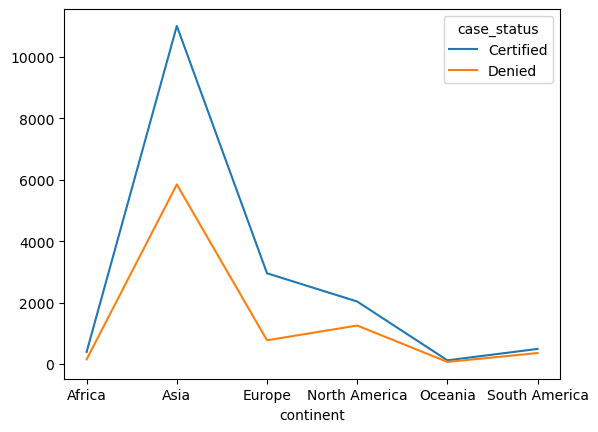

In [51]:
r1=pd.crosstab(col1,col2)       # line graph
r1.plot()

<Axes: xlabel='continent'>

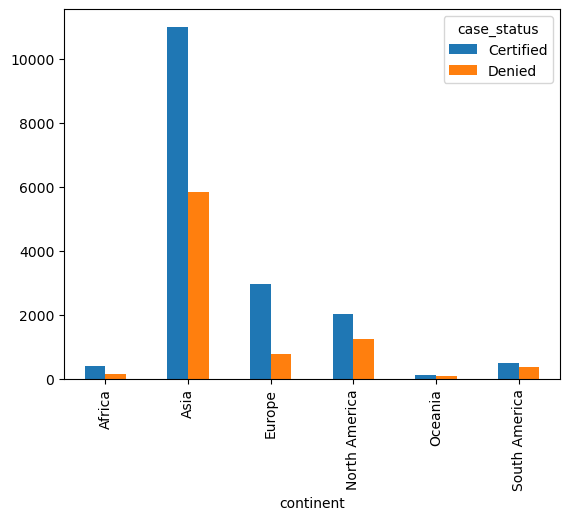

In [52]:
r1.plot(kind='bar')

**case status:-continent-education_of_employee**

In [53]:
# from asia there 16k applicants applied for visa
#    in that 11k+ ppl got certified
#        in that 11k ppl defferent education applicants are avaialable


# we want those information

In [54]:
pd.crosstab(index,columns,

_IncompleteInputError: incomplete input (1180858212.py, line 1)

In [55]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col1,col2]
pd.crosstab(col3,cols)

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

In [56]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2=pd.crosstab(col1,cols)
r2

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [ ]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
pd.crosstab(col1,cols)
r2.plot(kind='bar')

## GROUP-BY

In [57]:
visa_df['education_of_employee'].value_counts()

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

In [58]:
visa_df['prevailing_wage']
# numerical vlaues
# 25480 applicants are available 
# different applocants having the different wages

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [59]:
visa_df.groupby('education_of_employee')

In [60]:
list(visa_df.groupby('education_of_employee'))

[("Bachelor's",
           case_id      continent education_of_employee has_job_experience  \
  2         EZYV03           Asia            Bachelor's                  N   
  3         EZYV04           Asia            Bachelor's                  N   
  6         EZYV07           Asia            Bachelor's                  N   
  7         EZYV08  North America            Bachelor's                  Y   
  8         EZYV09           Asia            Bachelor's                  N   
  ...          ...            ...                   ...                ...   
  25466  EZYV25467         Europe            Bachelor's                  Y   
  25468  EZYV25469           Asia            Bachelor's                  N   
  25473  EZYV25474           Asia            Bachelor's                  Y   
  25475  EZYV25476           Asia            Bachelor's                  Y   
  25479  EZYV25480           Asia            Bachelor's                  Y   
  
        requires_job_training  no_of_employee

In [ ]:
visa_df.groupby('education_of_employee').count()

In [61]:
visa_df.groupby('education_of_employee').size()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
dtype: int64

In [62]:
# based on group by select an aonother column
visa_df.groupby('education_of_employee')['prevailing_wage']

In [63]:
visa_df['prevailing_wage'].mean()

np.float64(74455.81459209183)

In [64]:
visa_df[visa_df['education_of_employee']=="Bachelor's"]['prevailing_wage'].mean()

np.float64(73405.44373547)

In [65]:
visa_df.groupby('education_of_employee')['prevailing_wage'].mean()

education_of_employee
Bachelor's     73405.443735
Doctorate      64561.076657
High School    71582.147756
Master's       78843.057843
Name: prevailing_wage, dtype: float64

In [66]:
# i want continent people size
visa_df.groupby('continent').size()

continent
Africa             551
Asia             16861
Europe            3732
North America     3292
Oceania            192
South America      852
dtype: int64

In [67]:
con=visa_df['case_status']=='Certified'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [68]:
con=visa_df['case_status']=='Denied'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa            154
Asia             5849
Europe            775
North America    1255
Oceania            70
South America     359
dtype: int64

In [69]:
# i want to know min wage of the asia ppl manaully
visa_df['prevailing_wage'].min()
con=visa_df['continent']=='Asia'
new_df=visa_df[con]
new_df['prevailing_wage'].min()

3.3188

In [70]:
visa_df.groupby('continent')['prevailing_wage'].describe()

,count,mean,std,min,25%,50%,75%,max
continent,,,,,,,,
Africa,551.0,77425.923450,50526.872216,32.9286,40175.2650,75126.310,109361.4600,307716.10
Asia,16861.0,79543.021780,53521.083955,3.3188,40573.1300,76168.880,112538.4300,319210.27
Europe,3732.0,59842.925899,45293.362936,9.1753,24401.4825,52073.335,86730.5575,284328.96
North America,3292.0,68066.319257,53323.892898,2.1367,23703.2050,64289.875,104232.4250,306206.67
Oceania,192.0,75994.276719,56449.275624,24.4888,33132.5075,68656.045,107932.8050,275926.27
South America,852.0,60209.575314,50939.210197,3.0031,15613.8475,53511.705,94660.5500,255771.26


## 10-12-25

- we have seen case continent and case status

- we have seen three variables continent,case status and education of employee

- we also done similar analysis using group by

- only categorical column analysis completed

- only numerical column analysis completed

- also bi variate and multivariate analysis completed

- Now we need to perform two numnerical column analysis
    - This will give relation between two columns which are numerical in nature

    - so we can perform correlation matrix to get the relationship

    - also we need to perform scatterplots to visualize the relation

In [71]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [72]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

## plt.scatter

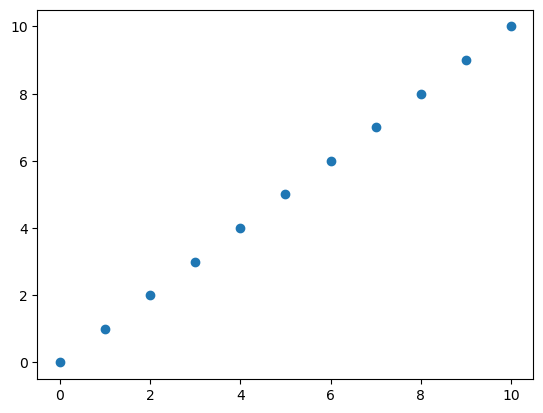

In [74]:
x=range(0,11)
y=range(0,11)
x,y
plt.scatter(x,y)

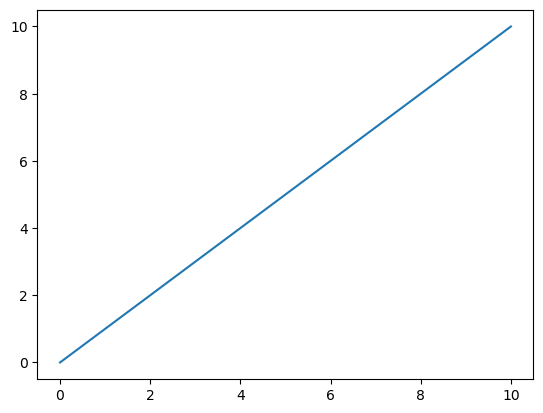

In [75]:
plt.plot(x,y)

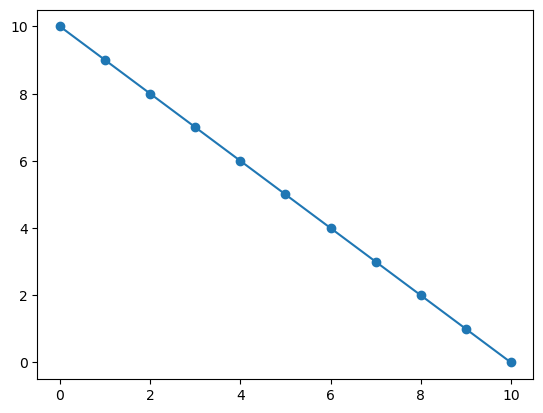

In [78]:
x=range(0,11)
y=range(10,-1,-1)
x,y
plt.scatter(x,y)
plt.plot(x,y)

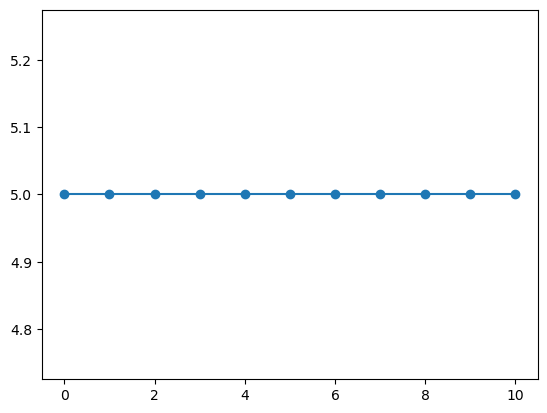

In [80]:
x=range(0,11)
y=[5 for i in range(0,11)]
x,y
plt.scatter(x,y)
plt.plot(x,y)

In [116]:
visa_df_corr=visa_df.corr(numeric_only=True)
visa_df_corr

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


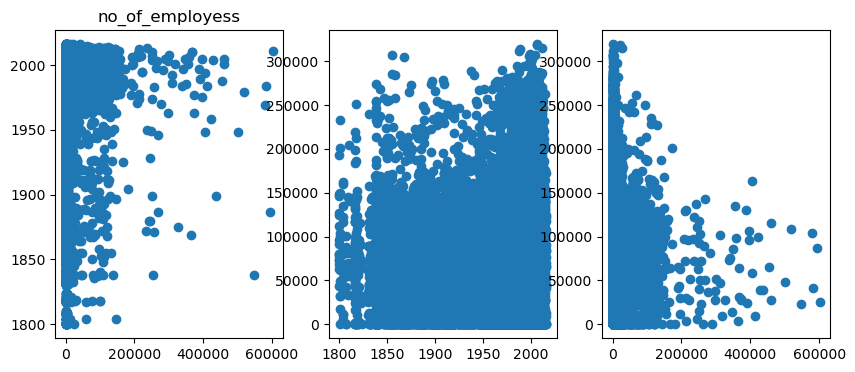

In [93]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(10,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.title('no_of_employess')
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

In [95]:
# winequality dataset
wine_quality=pd.read_csv('winequality_red.csv')

In [96]:
cat=wine_quality.select_dtypes(include='object')
num=wine_quality.select_dtypes(exclude='object')

In [97]:
cat

""
0
1
2
3
4
...
1594
1595
1596
1597


In [98]:
num

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [110]:
wine_data=wine_quality.corr(numeric_only=True)
wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


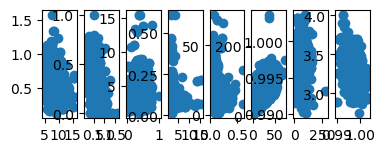

In [108]:
col1=wine_quality['fixed acidity']
col2=wine_quality['volatile acidity']
col3=wine_quality['citric acid']
col4=wine_quality['residual sugar']
col5=wine_quality['chlorides']
col6=wine_quality['free sulfur dioxide']
col7=wine_quality['total sulfur dioxide']
col8=wine_quality['density']
col9=wine_quality['pH']
col10=wine_quality['sulphates']
col11=wine_quality['alcohol']
col12=wine_quality['quality']
plt.subplot(3,12,1).scatter(col1,col2)
plt.subplot(3,12,2).scatter(col2,col3)
plt.subplot(3,12,3).scatter(col3,col4)
plt.subplot(3,12,4).scatter(col4,col5)
plt.subplot(3,12,5).scatter(col5,col6)
plt.subplot(3,12,6).scatter(col6,col7)
plt.subplot(3,12,7).scatter(col7,col8)
plt.subplot(3,12,8).scatter(col8,col9)

## heat map

- any matrix values we can visualize using a heat map

- Heat map will provide colors for different values

- Heat map also provides colors bar which indiacated,the colour and its value

- For example the values ranges from 0.8 to 1 display as **blue_color**

- so we need to check values we can directly see the blue clor

- so immediately we can sense blue color means highest values which is 0.8 to 1

- heatmap available in **seaborn**

<Axes: >

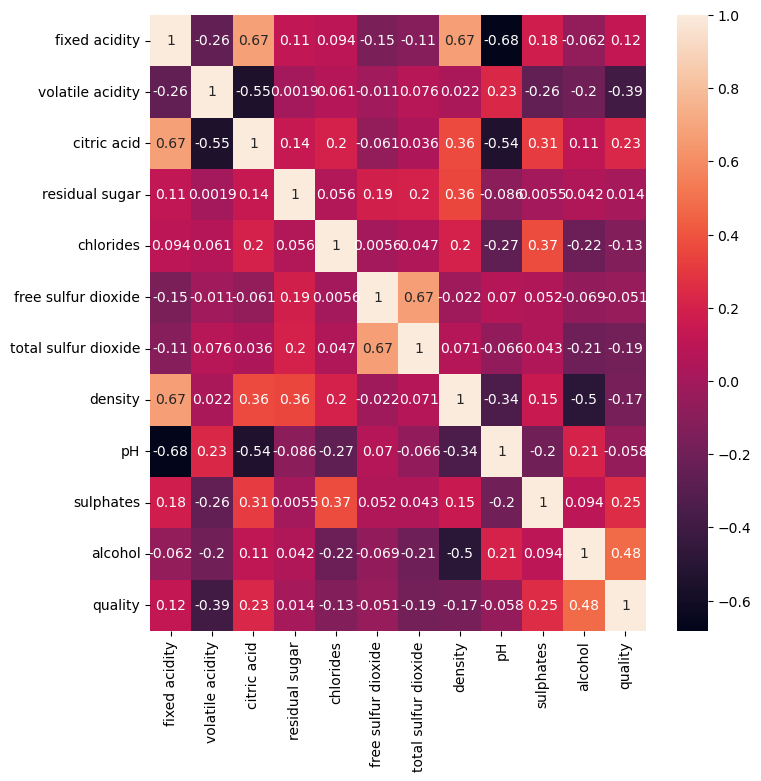

In [114]:
plt.figure(figsize=(8,8))
sns.heatmap(wine_data,annot=True)

<Axes: >

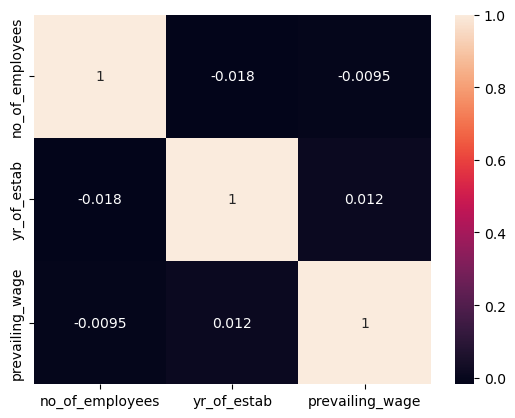

In [117]:
sns.heatmap(visa_df_corr,annot=True)

In [118]:
wine_data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

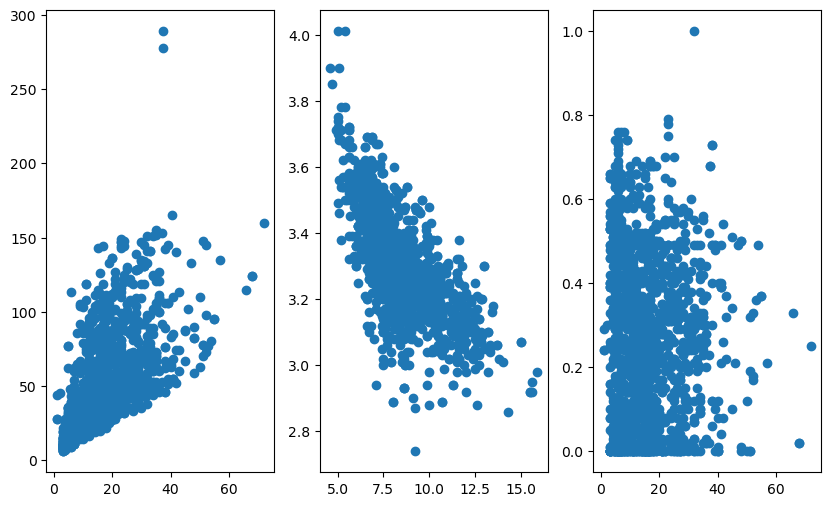

In [123]:
col1=wine_quality['free sulfur dioxide']
col2=wine_quality['total sulfur dioxide']
col3=wine_quality['fixed acidity']
col4=wine_quality['pH']
col5=wine_quality['citric acid']
plt.figure(figsize=(10,6))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col3,col4)
plt.subplot(1,3,3).scatter(col1,col5)

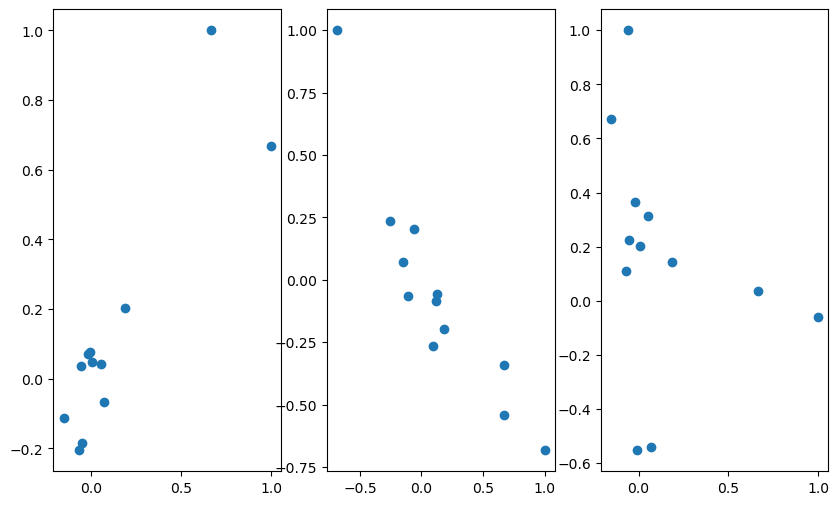

In [124]:
col1=wine_data['free sulfur dioxide']
col2=wine_data['total sulfur dioxide']
col3=wine_data['fixed acidity']
col4=wine_data['pH']
col5=wine_data['citric acid']
plt.figure(figsize=(10,6))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col3,col4)
plt.subplot(1,3,3).scatter(col1,col5)